# 1 Import Libraries

In [120]:
# ==============================
# 1️⃣ Import Required Libraries
# ==============================

import matplotlib.pyplot as plt        # For plotting graphs (accuracy/loss)
import seaborn as sns                  # For advanced visualizations (heatmap)
import pandas as pd                    # For handling dataset

import tensorflow as tf                # Main deep learning framework
from tensorflow import keras           # High-level API


Data set link - 
https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset

# 2 Image Data Preprocessing

### 2.1 traing Image

In [121]:
train_data = keras.utils.image_dataset_from_directory(
    'train',
    label_mode='categorical',   # 38 classes → one-hot encoding
    image_size=(224, 224),
    batch_size=32,
    shuffle=True
)

Found 8891 files belonging to 13 classes.




training_data = keras.utils.image_dataset_from_directory(
    directory='train',          # Path to training folder
    labels='inferred',          # Automatically infer labels from folder names
    label_mode='categorical',   # Multi-class classification (one-hot encoding)
    batch_size=32,              # Number of images per batch
    image_size=(128, 128),      # Resize all images to 128x128
    shuffle=True,               # Shuffle data to avoid memorization
    seed=42,                    # For reproducibility
    validation_split=None,      # No validation split here
    interpolation="bilinear",   # Resize method
    follow_links=False,         # Ignore symbolic links
    crop_to_aspect_ratio=False  # Do not crop image
)

| Parameter            | Default Value | Need to Write?                      |
| -------------------- | ------------- | ----------------------------------- |
| labels               | "inferred"    | ❌ Already default                   |
| seed                 | None          | ❌ Only needed with validation_split |
| validation_split     | None          | ❌ Not using split                   |
| interpolation        | "bilinear"    | ❌ Default                           |
| follow_links         | False         | ❌ Default                           |
| crop_to_aspect_ratio | False         | ❌ Default                           |


### 2.2 Valid image

In [122]:
valid_data = tf.keras.utils.image_dataset_from_directory(
    'valid',                    # Path to validation folder
    label_mode='categorical',   # Multi-class (38 classes → one-hot)
    image_size=(224, 224),      # Resize images
    batch_size=32,              # 32 images per batch
    shuffle=False               # No need to shuffle validation data
)

Found 6762 files belonging to 13 classes.


# 2.3 Test Image

In [123]:
test_data = tf.keras.utils.image_dataset_from_directory(
    'valid',                    # Path to validation folder
    label_mode='categorical',   # Multi-class (38 classes → one-hot)
    image_size=(224, 224),      # Resize images
    batch_size=32,              # 32 images per batch
    shuffle=False               # No need to shuffle validation data
)

Found 6762 files belonging to 13 classes.


In [124]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_data = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'train',
    target_size=(224, 224),   # ✅ MUST MATCH
    batch_size=32,
    class_mode='categorical'
)

valid_data = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'valid',
    target_size=(224, 224),   # ✅ MUST MATCH
    batch_size=32,
    class_mode='categorical'
)

Found 8891 images belonging to 13 classes.
Found 6762 images belonging to 13 classes.


Chek data

In [125]:
train_data

In [126]:
for x, y in train_data:
    print('img shape ' , x.shape)   # Image batch shape
    print('label shape', y.shape)   # Label batch shape
    break

img shape  (32, 224, 224, 3)
label shape (32, 13)


batch_size = 32

image_size = (128,128)

color_mode = 'rgb'

38 classes

img shape  (32, 128, 128, 3)

| Value | Meaning      |
| ----- | ------------ |
| 32    | Batch size   |
| 128   | Height       |
| 128   | Width        |
| 3     | RGB channels |


label shape (32, 38)
| Value | Meaning                             |
| ----- | ----------------------------------- |
| 32    | Batch size                          |
| 38    | Number of classes (one-hot encoded) |


In [127]:
valid_data

In [128]:
for x, y in valid_data:
    print('img shape ' , x.shape)   # Image batch shape
    print('label shape', y.shape)   # Label batch shape
    break

img shape  (32, 224, 224, 3)
label shape (32, 13)


# 3 Build CNN Arch

In [129]:
# models
from keras.models import Sequential   # model
from keras.layers import (Dense, Conv2D, Dropout, 
                          BatchNormalization, 
                          Flatten, MaxPool2D,Concatenate,GlobalAveragePooling2D) # Layer
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras import layers, models

In [130]:
# create model
model = Sequential()

In [131]:
# Create Layer 1 (First Convolution Layer)

model.add(Conv2D(
    32,                 # Number of filters
    kernel_size=3,      # Size of convolution filter
    padding='same',     # Output size same as input
    activation='relu',  # Activation function
    input_shape=(128,128,3)  # Input image shape
))

In [132]:
# create Layer 2
model.add(Conv2D(
    64,                 # Number of filters
    kernel_size=3,      # Size of convolution filter
    padding='same',     # Output size same as input
    activation='relu',  # Activation function
))

In [133]:
# add pooling
model.add(MaxPool2D(pool_size=2,strides=2))

MaxPooling is used to:

✔ Reduce image size

✔ Reduce computation

✔ Keep important features

✔ Prevent overfitting

In [134]:
# Create  Layer 3
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))
model.add(Dropout(0.15)) # Randomly drops 15% neurons → prevents overfitting
model.add(BatchNormalization()) # Normalizes output → faster & stable training


In [135]:
# Create  Layer 4
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))
model.add(Dropout(0.2)) # Randomly drops 15% neurons → prevents overfitting
model.add(BatchNormalization()) # Normalizes output → faster & stable training


In [136]:
# flatten
#model.add(Flatten())
# Converts 2D feature maps into 1D vector
# Required before connecting to Dense (Fully Connected) layers

In [137]:
model.add(GlobalAveragePooling2D()) 

(batch_size, height, width, channels)

Example:  
(32, 16, 16, 64)

After flat  
(32, 16384)

fun
16 × 16 × 64 = 16384

In [138]:
# add dense
model.add(Dense(1500,activation='relu'))

In [139]:
model.add(Dropout(0.4))

In [140]:
#Output Layer
model.add(Dense(units=13 ,activation='softmax'))

# 4 Model Compilling

In [141]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [142]:
# summary
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_21 (Conv2D)          (None, 128, 128, 32)      896       
                                                                 
 conv2d_22 (Conv2D)          (None, 128, 128, 64)      18496     
                                                                 
 max_pooling2d_15 (MaxPooli  (None, 64, 64, 64)        0         
 ng2D)                                                           
                                                                 
 conv2d_23 (Conv2D)          (None, 64, 64, 64)        36928     
                                                                 
 max_pooling2d_16 (MaxPooli  (None, 32, 32, 64)        0         
 ng2D)                                                           
                                                                 
 dropout_17 (Dropout)        (None, 32, 32, 64)       

# 5 Model Training

5.1 Early Stoping

In [143]:
# Import EarlyStopping class from Keras callbacks module
from keras.callbacks import EarlyStopping


# Create EarlyStopping object and store in variable 'callback'
callback = EarlyStopping(

    monitor='val_loss',        # Metric to monitor (validation loss)

    min_delta=0.01,            # Minimum change required to count as improvement

    patience=5,                # Number of epochs to wait before stopping if no improvement

    verbose=1,                 # Print message when early stopping happens (1 = show message)

    mode='auto',               # Automatically decide min/max based on monitored metric

    baseline=None,             # Training will stop if model doesn't reach this baseline value (None = ignore)

    restore_best_weights=True, # After stopping, restore weights from best epoch

    start_from_epoch=0         # Start monitoring from this epoch number
)

5.2 Model training

In [ ]:
training_history = model.fit(
    train_data,                 # Training dataset
    validation_data=valid_data, # Validation dataset
    epochs=20,                  # Number of training cycles
    verbose=1 ,                  # Show training progress
    callbacks=[callback]        # Custom callbacks (like EarlyStopping)
)

Epoch 1/20
  6/278 [..............................] - ETA: 17:07 - loss: 2.5681 - accuracy: 0.0781

In [ ]:
training_history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

In [ ]:
training_history.history['loss']

[2.353696823120117,
 2.2013661861419678,
 2.117100238800049,
 2.0497446060180664,
 1.970996618270874,
 1.9055160284042358,
 1.8297526836395264,
 1.772902011871338,
 1.7123321294784546,
 1.6617335081100464,
 1.61123526096344,
 1.5543664693832397,
 1.5175772905349731,
 1.4622164964675903,
 1.4281829595565796,
 1.3807872533798218,
 1.3434029817581177,
 1.3060392141342163,
 1.2731523513793945,
 1.2333742380142212]

In [ ]:
#Model Evaluation on Training set
train_loss,train_acc = model.evaluate(train_data)

val_loss,val_acc = model.evaluate(valid_data)

212/212 [==============================] - 144s 680ms/step - loss: 1.3042 - accuracy: 0.5781


In [ ]:
#Model on Validation set
# val_loss,val_acc = model.evaluate(valid_data)

In [ ]:
print('Train')
print(f'train_loss - {train_loss}\ntrain_acc - {train_acc}\n')
print('Test')
print(f'test_loss - {val_loss}\ntest_acc - {val_acc}')

Train
train_loss - 1.2745418548583984
train_acc - 0.5899223685264587

Test
test_loss - 1.304164171218872
test_acc - 0.5780833959579468


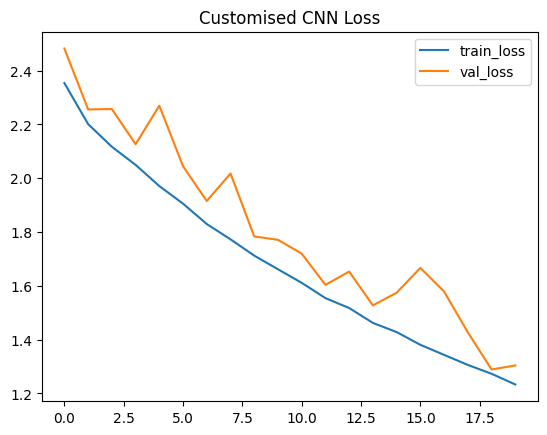

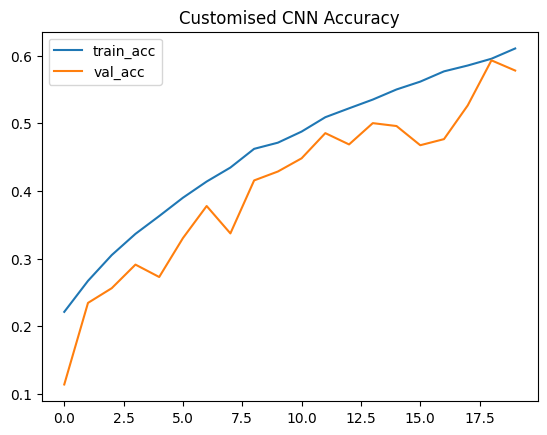

In [ ]:

# Loss curve
plt.plot(training_history.history['loss'], label='train_loss')
plt.plot(training_history.history['val_loss'], label='val_loss')
plt.legend()
plt.title('Customised CNN Loss')
plt.show()

# Accuracy curve
plt.plot(training_history.history['accuracy'], label='train_acc')
plt.plot(training_history.history['val_accuracy'], label='val_acc')
plt.title('Customised CNN Accuracy')
plt.legend()
plt.show()

# 6 Build MobileNet Model

In [ ]:
# mobilenet 


In [ ]:
from tensorflow.keras.applications import MobileNetV3Small

# Load pretrained MobileNetV3Small
mobile_model = MobileNetV3Small(
    input_shape=(224, 224, 3),
    alpha=1.0,
    minimalistic=False,
    include_top=False,
    weights='imagenet',
    pooling='avg'   # GlobalAveragePooling included
)


In [ ]:
#mobile_model.summary()

In [ ]:
# Freeze base model (do not train pretrained layers first)
mobile_model.trainable = False

In [ ]:
# Build model
model_1 = models.Sequential([
    mobile_model,               # Pretrained feature extractor
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(13, activation='softmax')
])

In [ ]:
# compile model
model_1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),  # Stable LR
    loss='categorical_crossentropy',                         # Multi-class
    metrics=['accuracy']                                     # Track accuracy
)

In [ ]:
# Train model
mobile_history = model.fit(
    train_data,                 # Training dataset
    validation_data=valid_data, # Validation dataset
    epochs=20,                  # Number of training cycles
    verbose=1                   # Show progress bar
)

Epoch 1/20
278/278 [==============================] - 1177s 4s/step - loss: 1.1824 - accuracy: 0.6261 - val_loss: 1.3384 - val_accuracy: 0.5867
Epoch 2/20
278/278 [==============================] - 1162s 4s/step - loss: 1.1613 - accuracy: 0.6311 - val_loss: 1.2986 - val_accuracy: 0.5645
Epoch 3/20
278/278 [==============================] - 1173s 4s/step - loss: 1.1369 - accuracy: 0.6491 - val_loss: 1.2327 - val_accuracy: 0.6047
Epoch 4/20
278/278 [==============================] - 1175s 4s/step - loss: 1.0932 - accuracy: 0.6565 - val_loss: 1.1884 - val_accuracy: 0.6217
Epoch 5/20
278/278 [==============================] - 1171s 4s/step - loss: 1.0848 - accuracy: 0.6575 - val_loss: 1.2748 - val_accuracy: 0.5818
Epoch 6/20
278/278 [==============================] - 1178s 4s/step - loss: 1.0427 - accuracy: 0.6729 - val_loss: 1.2521 - val_accuracy: 0.5856
Epoch 7/20
278/278 [==============================] - 1182s 4s/step - loss: 1.0159 - accuracy: 0.6771 - val_loss: 1.2379 - val_accuracy:

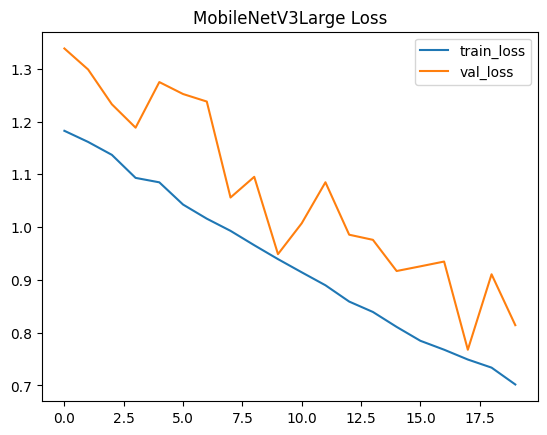

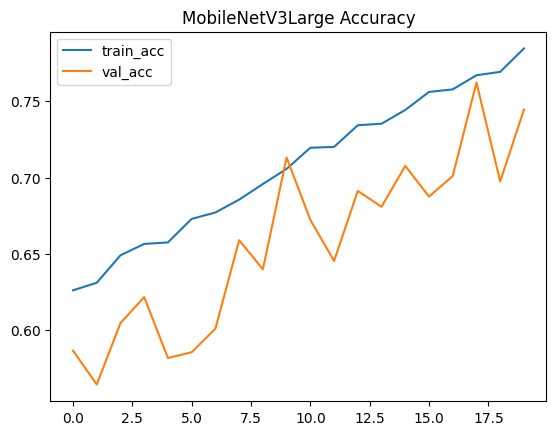

In [ ]:

# Loss curve
plt.plot(mobile_history.history['loss'], label='train_loss')
plt.plot(mobile_history.history['val_loss'], label='val_loss')
plt.legend()
plt.title('MobileNetV3Large Loss')
plt.show()

# Accuracy curve
plt.plot(mobile_history.history['accuracy'], label='train_acc')
plt.plot(mobile_history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title('MobileNetV3Large Accuracy')
plt.show()

In [ ]:
mobile_history.history

{'loss': [1.1824322938919067,
  1.1613235473632812,
  1.1368591785430908,
  1.0932087898254395,
  1.0847920179367065,
  1.0426714420318604,
  1.015925645828247,
  0.9928469657897949,
  0.9656276702880859,
  0.9392716884613037,
  0.9142841696739197,
  0.8897209763526917,
  0.858840823173523,
  0.8391252756118774,
  0.810820460319519,
  0.7845109701156616,
  0.7676190137863159,
  0.7489979267120361,
  0.7336388230323792,
  0.701722264289856],
 'accuracy': [0.6261388063430786,
  0.631087601184845,
  0.6490833163261414,
  0.6565065979957581,
  0.6575188636779785,
  0.6729276776313782,
  0.6770892143249512,
  0.6855247020721436,
  0.6957597732543945,
  0.705657422542572,
  0.7194916009902954,
  0.7200539708137512,
  0.7342256307601929,
  0.7352378964424133,
  0.7442357540130615,
  0.7560454607009888,
  0.7577325105667114,
  0.7669553756713867,
  0.7692047953605652,
  0.7845011949539185],
 'val_loss': [1.3384374380111694,
  1.2985725402832031,
  1.2327197790145874,
  1.1883680820465088,
  1.

# Fusion Model

In [ ]:
from tensorflow.keras.layers import Input

In [ ]:
input_layer = Input(shape=(224,224,3))

In [ ]:
# cnn
x = Conv2D(32,3,padding='same',activation='relu')(input_layer)
x = Conv2D(32,3,padding='same',activation='relu')(x)
x = MaxPool2D(2,2)(x)

x = Conv2D(64,3,padding='same',activation='relu')(x)
x = MaxPool2D(2,2)(x)
x = Dropout(0.15)(x)
x = BatchNormalization()(x)

x = Conv2D(64,3,padding='same',activation='relu')(x)
x = MaxPool2D(2,2)(x)
x = Dropout(0.2)(x)
x = BatchNormalization()(x)

x = GlobalAveragePooling2D()(x)
x = Dense(256,activation='relu')(x)

In [ ]:
# mobile
from tensorflow.keras.applications import MobileNetV3Large

mobilenet = MobileNetV3Large(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)

mobilenet.trainable = False

y = mobilenet(input_layer)

In [ ]:
# fusion
fusion_model = Concatenate()([x, y])

In [ ]:
# clas
z = Dense(256,activation='relu')(fusion_model)
z = Dropout(0.4)(z)

output = Dense(13,activation='softmax')(z)

In [ ]:
from tensorflow.keras.models import Model

fusion_model = Model(inputs=input_layer, outputs=output)

In [ ]:
fusion_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:

fusion_history = fusion_model.fit(
    train_data,                 # Training dataset
    validation_data=valid_data, # Validation dataset
    epochs=20, # Number of training cycles
    verbose=1,  # Show training progress     
    callbacks=[callback]        # Custom callbacks (like EarlyStopping)
)

Epoch 1/20
278/278 [==============================] - 1043s 4s/step - loss: 2.4269 - accuracy: 0.1828 - val_loss: 2.4770 - val_accuracy: 0.1671
Epoch 2/20
278/278 [==============================] - 1046s 4s/step - loss: 2.2213 - accuracy: 0.2634 - val_loss: 2.3200 - val_accuracy: 0.2249
Epoch 3/20
278/278 [==============================] - 1031s 4s/step - loss: 2.1319 - accuracy: 0.2941 - val_loss: 2.1511 - val_accuracy: 0.2808
Epoch 4/20
278/278 [==============================] - 1050s 4s/step - loss: 2.0610 - accuracy: 0.3229 - val_loss: 2.0525 - val_accuracy: 0.3385
Epoch 5/20
278/278 [==============================] - 1030s 4s/step - loss: 1.9918 - accuracy: 0.3536 - val_loss: 1.9938 - val_accuracy: 0.3320
Epoch 6/20
278/278 [==============================] - 1058s 4s/step - loss: 1.9271 - accuracy: 0.3733 - val_loss: 1.8548 - val_accuracy: 0.4110
Epoch 7/20
278/278 [==============================] - 1035s 4s/step - loss: 1.8599 - accuracy: 0.3998 - val_loss: 1.9481 - val_accuracy:

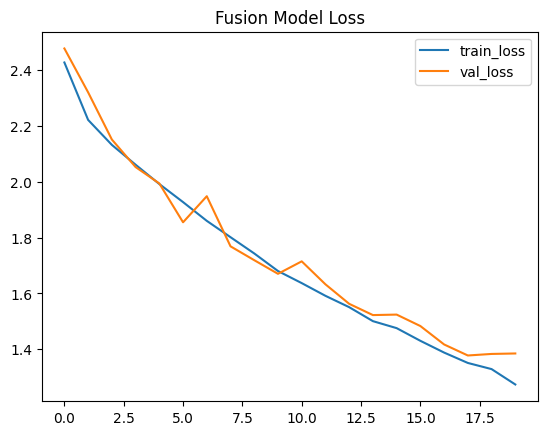

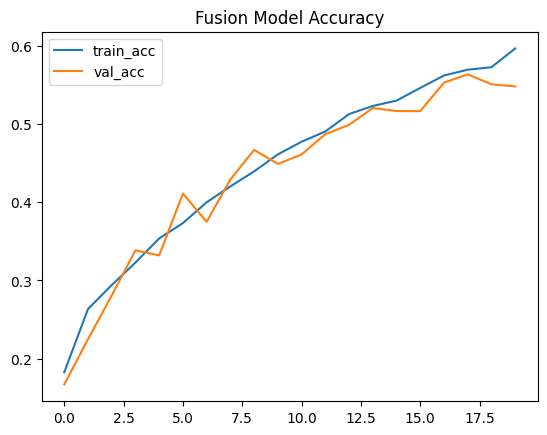

In [ ]:

# Loss curve
plt.plot(fusion_history.history['loss'], label='train_loss')
plt.plot(fusion_history.history['val_loss'], label='val_loss')
plt.legend()
plt.title('Fusion Model Loss')
plt.show()

# Accuracy curve
plt.plot(fusion_history.history['accuracy'], label='train_acc')
plt.plot(fusion_history.history['val_accuracy'], label='val_acc')
plt.title('Fusion Model Accuracy')
plt.legend()
plt.show()

In [ ]:
model.save("pest_1.keras")
fusion_model.save("pest_3.keras")
mobile_model.save("pest_2.keras")

In [ ]:
y_pred = model.predict(test_data)
predicted_categories = tf.argmax(y_pred,axis=1)
true_categories = tf.concat([y for x,y in test_data],axis=0)
Y_true = tf.argmax(true_categories,axis=1)


from sklearn.metrics import classification_report,confusion_matrix

report = classification_report(Y_true, predicted_categories, target_names=test_data.class_names)
print(report)

ValueError: in user code:

    File "C:\Users\Student\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\engine\training.py", line 2416, in predict_function  *
        return step_function(self, iterator)
    File "C:\Users\Student\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\engine\training.py", line 2401, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "C:\Users\Student\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\engine\training.py", line 2389, in run_step  **
        outputs = model.predict_step(data)
    File "C:\Users\Student\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\engine\traini

In [ ]:
y_pred = mobile_model.predict(test_data)
predicted_categories = tf.argmax(y_pred,axis=1)
true_categories = tf.concat([y for x,y in test_data],axis=0)
Y_true = tf.argmax(true_categories,axis=1)


from sklearn.metrics import classification_report,confusion_matrix

report = classification_report(Y_true, predicted_categories, target_names=test_data.class_names)
print(report)

In [ ]:
y_pred = fusion_model.predict(test_data)
predicted_categories = tf.argmax(y_pred,axis=1)
true_categories = tf.concat([y for x,y in test_data],axis=0)
Y_true = tf.argmax(true_categories,axis=1)


from sklearn.metrics import classification_report,confusion_matrix

report = classification_report(Y_true, predicted_categories, target_names=test_data.class_names)
print(report)

In [ ]:
y_pred = fusion_model.predict(test_data)
y_pred,y_pred.shape

550/550 ━━━━━━━━━━━━━━━━━━━━ 138s 248ms/step


(array([[1.0000000e+00, 3.7724047e-12, 1.9392203e-09, ..., 1.7491628e-19,
         1.7083534e-23, 5.2122041e-19],
        [1.0000000e+00, 2.3253040e-12, 2.7072367e-10, ..., 1.5427536e-19,
         6.7062328e-24, 4.9127811e-20],
        [1.0000000e+00, 2.5943692e-13, 3.5520265e-09, ..., 5.1768327e-27,
         2.3023785e-22, 1.2692968e-18],
        ...,
        [2.6302594e-16, 2.6384505e-23, 5.8439158e-13, ..., 9.2526654e-21,
         3.6772724e-20, 1.0000000e+00],
        [1.0888707e-10, 1.5553820e-15, 8.5778481e-16, ..., 3.3698637e-16,
         1.7749370e-19, 9.9999070e-01],
        [7.9027293e-21, 4.9860153e-21, 1.1161742e-27, ..., 2.7957038e-30,
         1.0619564e-21, 1.0000000e+00]], shape=(17572, 38), dtype=float32),
 (17572, 38))

In [ ]:
predicted_categories = tf.argmax(y_pred,axis=1)
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], shape=(17572,))>

In [ ]:
true_categories = tf.concat([y for x,y in test_data],axis=0)
true_categories

<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(17572, 38), dtype=float32)>

In [ ]:
Y_true = tf.argmax(true_categories,axis=1)
Y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], shape=(17572,))>

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix

In [ ]:
report = classification_report(Y_true, predicted_categories, target_names=test_data.class_names)
print(report)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      0.98      0.99       504
                                 Apple___Black_rot       0.99      1.00      1.00       497
                          Apple___Cedar_apple_rust       1.00      1.00      1.00       440
                                   Apple___healthy       0.99      1.00      0.99       502
                               Blueberry___healthy       1.00      0.99      1.00       454
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       421
                 Cherry_(including_sour)___healthy       1.00      1.00      1.00       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.96      0.96      0.96       410
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       477
               Corn_(maize)___Northern_Leaf_Blight       0.97      0.97      0.

# SAve model

In [ ]:
#Recording History in json
import json
with open("training_hist.json","w") as f:
    json.dump(training_history.history,f)